<a href="https://colab.research.google.com/github/nomanahmed21/AutoTuneAI/blob/main/Automated_HyperParamet_Tunning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/python_libs')

In [ ]:
from agent import BayesianAutoTuneAgent

In [ ]:
# ===============================
# Imports
# ===============================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import random
import json

from sklearn.model_selection import train_test_split

# ===============================
# Seed
# ===============================
SEED = 41
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ===============================
# Load Data
# ===============================
df = pd.read_csv(
    "https://raw.githubusercontent.com/nomanahmed21/Credit-Card-Fraud-Detection/refs/heads/main/processed_data.csv"
)

df.drop("Unnamed: 0", axis=1, inplace=True)

# ===============================
# Dataset
# ===============================
class FraudDataset(Dataset):
    def __init__(self, df):
        self.X = df.drop("is_fraud", axis=1).values.astype(np.float32)
        self.y = df["is_fraud"].values.astype(np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])

# ===============================
# Train / Test Split
# ===============================
train_df, temp_df = train_test_split(
      df,
      test_size=0.3,
      stratify=df["is_fraud"],
      random_state=SEED
)

val_df, test_df = train_test_split(
      temp_df,
      test_size=0.67,   # 20% test, 10% val
      stratify=temp_df["is_fraud"],
      random_state=SEED
)

train_data = FraudDataset(train_df)
val_data   = FraudDataset(val_df)
test_data  = FraudDataset(test_df)

# ===============================
# Class Weights (Imbalance Handling)
# ===============================
fraud = train_df["is_fraud"].sum()
normal = len(train_df) - fraud

class_weights = torch.tensor(
    [1.0, normal / fraud], dtype=torch.float32
)

# ===============================
# Model
# ===============================
class FraudModel(nn.Module):
    def __init__(self, in_features, h1, h2, out_features=2):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)

# ===============================
# Train + Evaluate Function
# ===============================
def train_fn(config):
    # Config
    epochs = config["epochs"]
    lr = config["lr"]
    h1 = config["h1"]
    h2 = config["h2"]
    batch_size = config["batch_size"]
    threshold = config.get("threshold", 0.5)

    # DataLoaders
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

    # Model
    model = FraudModel(
        in_features=train_data.X.shape[1],
        h1=h1,
        h2=h2
    )

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Training
    model.train()
    for _ in range(epochs):
        for X, y in train_loader:
            preds = model(X)
            loss = criterion(preds, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    TP = TN = FP = FN = 0

    with torch.no_grad():
        for X, y in val_loader:
            logits = model(X)
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = (probs > threshold).long()

            TP += ((preds == 1) & (y == 1)).sum().item()
            TN += ((preds == 0) & (y == 0)).sum().item()
            FP += ((preds == 1) & (y == 0)).sum().item()
            FN += ((preds == 0) & (y == 1)).sum().item()

    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    print("TP FP FN:", TP, FP, FN)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)


    return f1

In [ ]:
search_space = {
    "epochs": [5,15],
    "lr": (1e-4, 1e-2),
    "batch_size": [16,64],
    "h1": [16,64],
    "h2": [8,32],
    "threshold": [0.5,0.75]
}

In [ ]:
agent = BayesianAutoTuneAgent(search_space, train_fn=train_fn, warmup_samples=50, max_workers=8)

🚀 Running parallel warmup with 50 samples...
TP FP FN: 11 32 4
Precision: 0.25581395342888047
Recall: 0.7333333328444444
F1: 0.37931034086206894
TP FP FN: 7 11 8
Precision: 0.3888888886728395
Recall: 0.46666666635555554
F1: 0.4242424190266299
TP FP FN: 1 1 14
Precision: 0.4999999975
Recall: 0.06666666662222222
F1: 0.11764705660899655
TP FP FN: 0 0 15
Precision: 0.0
Recall: 0.0
F1: 0.0
TP FP FN: 11 80 4
Precision: 0.12087912086583746
Recall: 0.7333333328444444
F1: 0.20754716734247067
TP FP FN: 6 45 9
Precision: 0.11764705880046136
Recall: 0.39999999973333333
F1: 0.18181817825068877
TP FP FN: 13 44 2
Precision: 0.22807017539858418
Recall: 0.8666666660888889
F1: 0.36111110771219146
TP FP FN: 0 0 15
Precision: 0.0
Recall: 0.0
F1: 0.0
TP FP FN: 10 2 5
Precision: 0.8333333326388889
Recall: 0.6666666662222221
F1: 0.7407407352537724
TP FP FN: 11 3 4
Precision: 0.7857142851530612
Recall: 0.7333333328444444
F1: 0.758620684137931
TP FP FN: 8 9 7
Precision: 0.470588235017301
Recall: 0.533333332977

In [ ]:
best = agent.run(
    train_fn=train_fn,
    trials=50,
    patience=15,
    parallel_eval=1
)

🔎 Exploring (σ=0.169, μ=0.567, EI=0.0089)
TP FP FN: 12 9 3
Precision: 0.5714285711564626
Recall: 0.7999999994666667
F1: 0.6666666614351853
Trial 1/50: score=0.6667 | best=0.7742
🔎 Exploring (σ=0.172, μ=0.571, EI=0.0100)
TP FP FN: 0 0 15
Precision: 0.0
Recall: 0.0
F1: 0.0
Trial 2/50: score=0.0000 | best=0.7742
🔎 Exploring (σ=0.179, μ=0.570, EI=0.0113)
TP FP FN: 9 0 6
Precision: 0.9999999988888888
Recall: 0.5999999996
F1: 0.7499999946874999
Trial 3/50: score=0.7500 | best=0.7742
🔎 Exploring (σ=0.180, μ=0.583, EI=0.0132)
TP FP FN: 2 0 13
Precision: 0.999999995
Recall: 0.13333333324444444
F1: 0.23529411529411765
Trial 4/50: score=0.2353 | best=0.7742
🔎 Exploring (σ=0.186, μ=0.554, EI=0.0107)
TP FP FN: 13 26 2
Precision: 0.33333333324786324
Recall: 0.8666666660888889
F1: 0.4814814772908094
Trial 5/50: score=0.4815 | best=0.7742
🔎 Exploring (σ=0.183, μ=0.556, EI=0.0103)
TP FP FN: 0 0 15
Precision: 0.0
Recall: 0.0
F1: 0.0
Trial 6/50: score=0.0000 | best=0.7742
🔎 Exploring (σ=0.202, μ=0.512, E

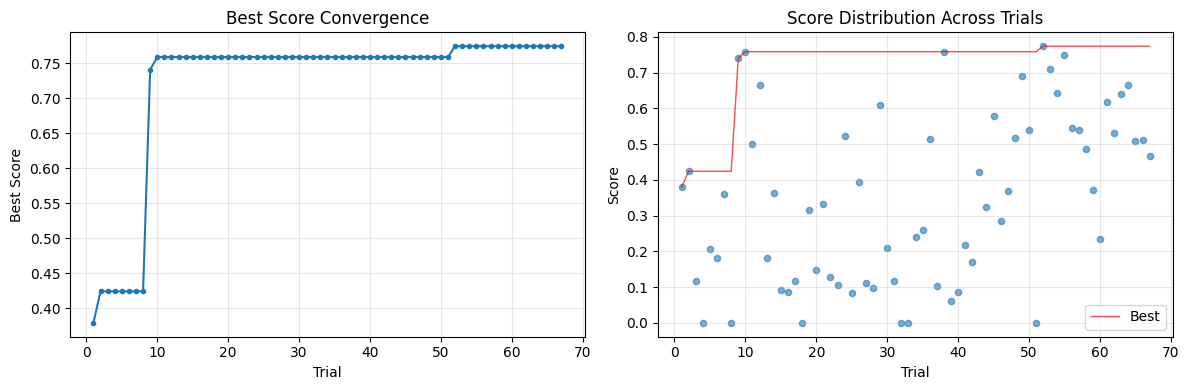

In [ ]:
agent.plot()

In [ ]:
best

{'config': {'epochs': 15,
  'lr': 0.005518681751148234,
  'batch_size': 16,
  'h1': 16,
  'h2': 8,
  'threshold': 0.75},
 'metrics': 0.7741935428928202}

In [ ]:
agent.load()

📂 Loaded 67 results from results.json
